In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_AC_stark_vals=[np.float64(-6.012809935183887e-05), np.float64(-9.501932447283222e-05), np.float64(-0.00019532999306232752), np.float64(-0.0003610601051203248), np.float64(-0.000492209660646824), np.float64(-0.000688778659641825), np.float64(-0.0008507671021053284), np.float64(-0.0010781749880373333), np.float64(-0.00137100231743784), np.float64(-0.0020292490903068487), np.float64(-0.0022529153066443586), np.float64(-0.002642000966450374), np.float64(-0.0032965060697248876), np.float64(-0.0025164306164679037), np.float64(-0.0035017746066794237), np.float64(-0.005052538040359444), np.float64(-0.0041687209175079645), np.float64(-0.006550323238124991), np.float64(-0.005597345002210516), np.float64(-0.004609786209764544)]

f_no_drag_vals=[np.float64(1.3436368489906216e-08), np.float64(3.930754524283052e-08), np.float64(8.012948525463497e-08), np.float64(1.371110034597807e-07), np.float64(2.1140574752935683e-07), np.float64(2.947976174719052e-07), np.float64(4.150673919663258e-07), np.float64(5.512024142776997e-07), np.float64(7.067675638842563e-07), np.float64(8.897797998202682e-07), np.float64(1.0954955761503094e-06), np.float64(1.3278873803496493e-06), np.float64(1.5690491180396615e-06), np.float64(1.8816974956137286e-06), np.float64(2.205728835839245e-06), np.float64(2.5629144306093446e-06), np.float64(2.951271241922989e-06), np.float64(3.371923382750762e-06), np.float64(3.824790211663999e-06), np.float64(4.326621007983556e-06)]

## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [9]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    avg_e_vals=[]
    avg_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        print(i)
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)
        
        if A < 0.13:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=20,drag=True,use_avg=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=20,drag=True,use_avg=True)

        avg_e_vals.append(sim_vals[0])
        avg_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, avg_e_vals)
    plt.semilogy(AC_stark_vals, avg_f_vals)
    plt.legend(["e","f"])
    plt.xlabel("ω_supp-ω_ef (GHz)")
    plt.ylabel("Tason todennäköisyyden keskiarvo")
    plt.show()
    
    index=np.argmin(avg_f_vals)
    AC_stark=AC_stark_vals[index]
    e_max=avg_e_vals[index]
    f_max=avg_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],avg_e_vals)

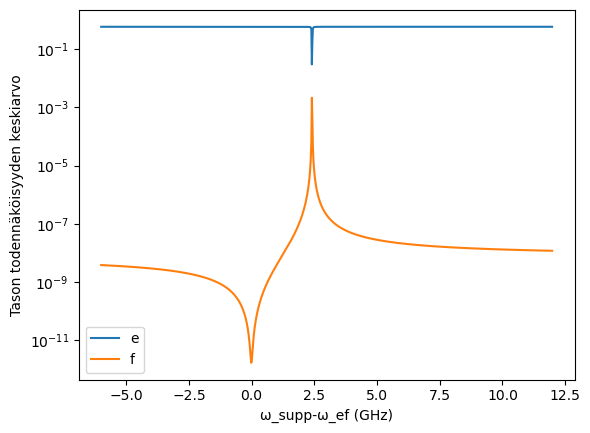

Amplitudi (GHz): 0.012744300694748212
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999953367006645
Pulssin pituus (ns): 251.57999227526173
Rabi-taajuus (fourier):  0.0020291591499556868


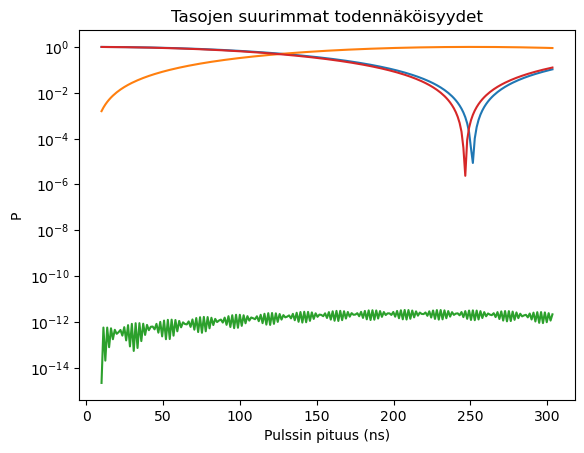

---------------------------------------------


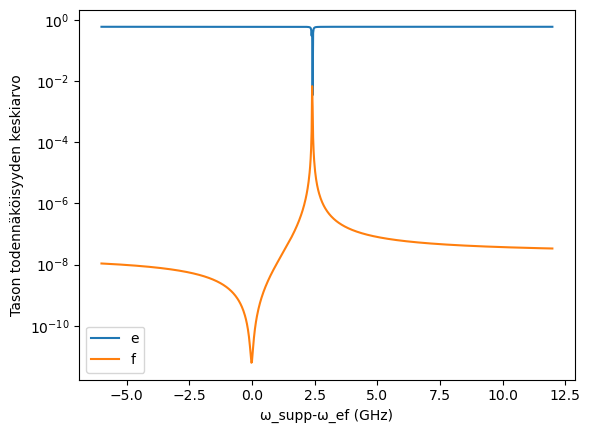

Amplitudi (GHz): 0.021464085380628568
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999993016939162
Pulssin pituus (ns): 150.51100417886914
Rabi-taajuus (fourier):  0.003418501500709659


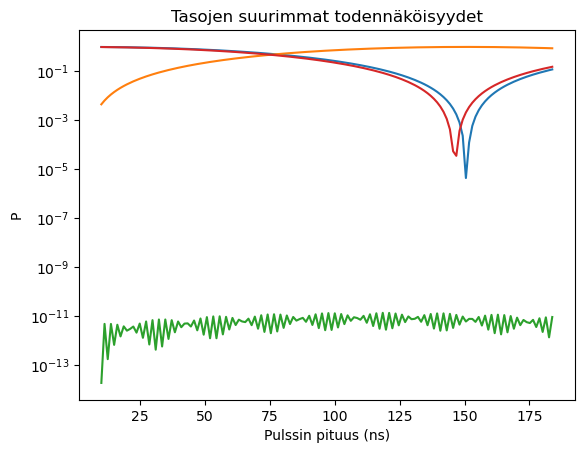

---------------------------------------------


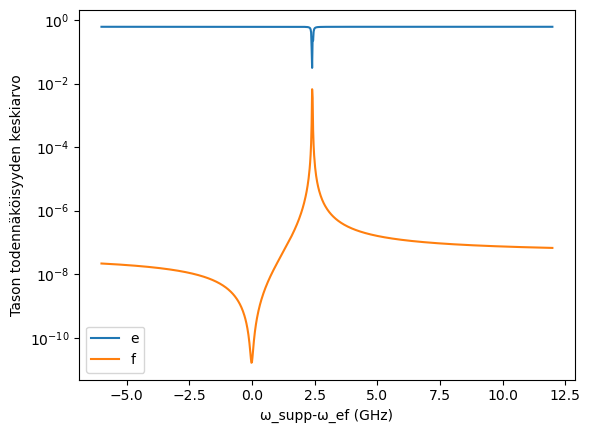

Amplitudi (GHz): 0.030183870066508925
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999996733490408
Pulssin pituus (ns): 108.60460151978626
Rabi-taajuus (fourier):  0.004805456050428481


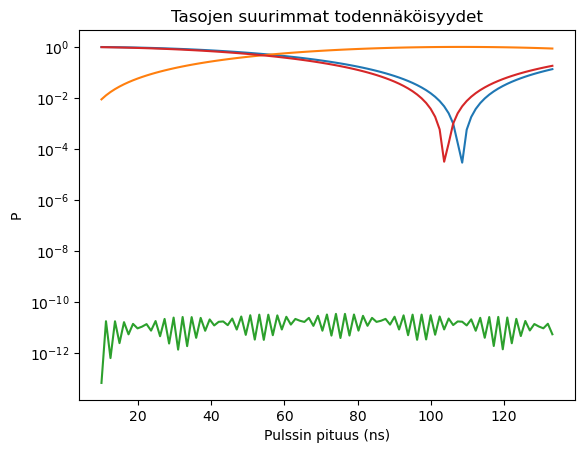

---------------------------------------------


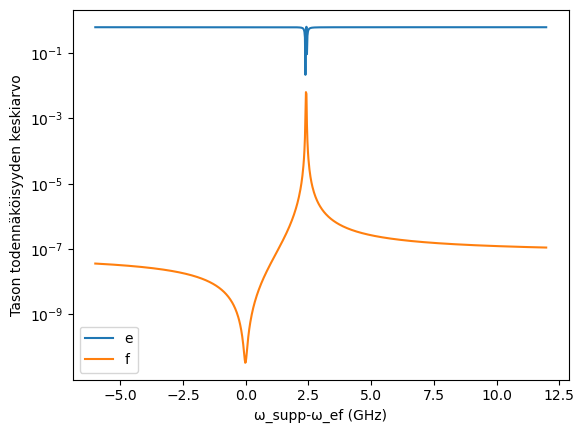

Amplitudi (GHz): 0.03890365475238928
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999967107851442
Pulssin pituus (ns): 83.95393200135018
Rabi-taajuus (fourier):  0.0061932510521172865


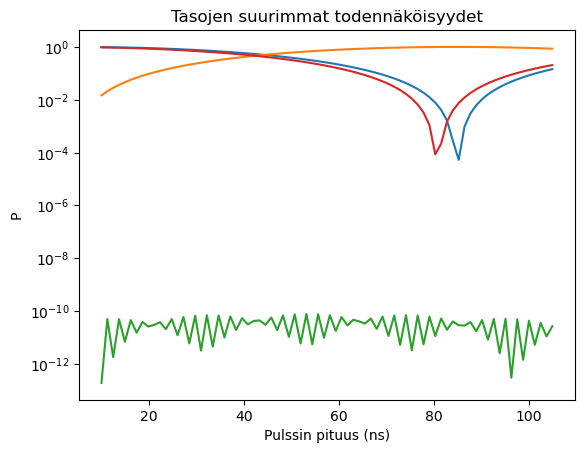

---------------------------------------------


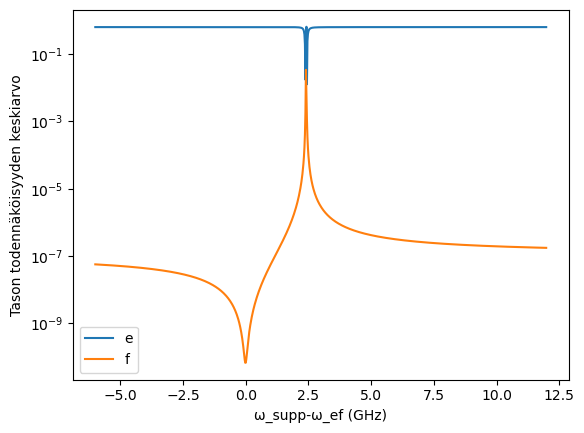

Amplitudi (GHz): 0.04762343943826964
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999993663141789
Pulssin pituus (ns): 69.16345002618263
Rabi-taajuus (fourier):  0.007582352459881833


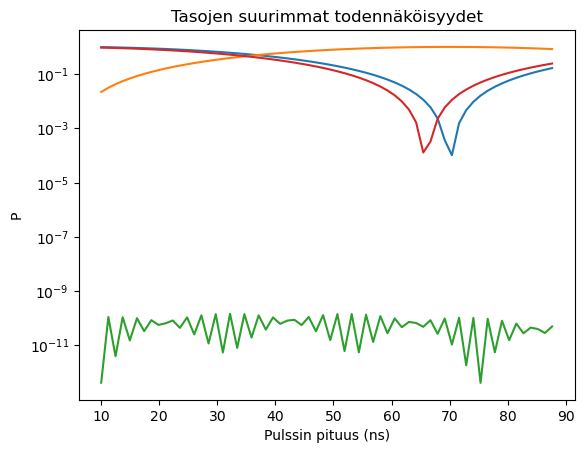

---------------------------------------------


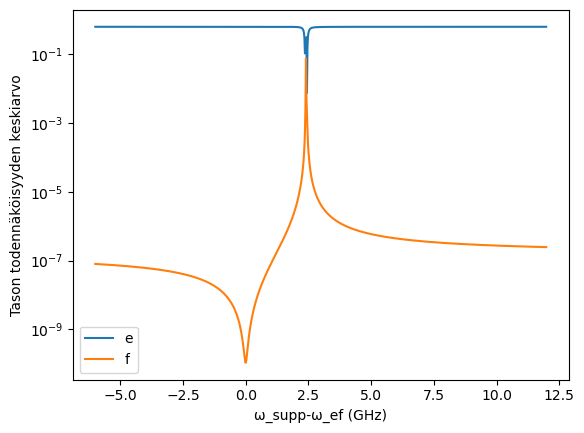

Amplitudi (GHz): 0.05634322412415
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999995019293609
Pulssin pituus (ns): 59.30325525761684
Rabi-taajuus (fourier):  0.008981241212787306


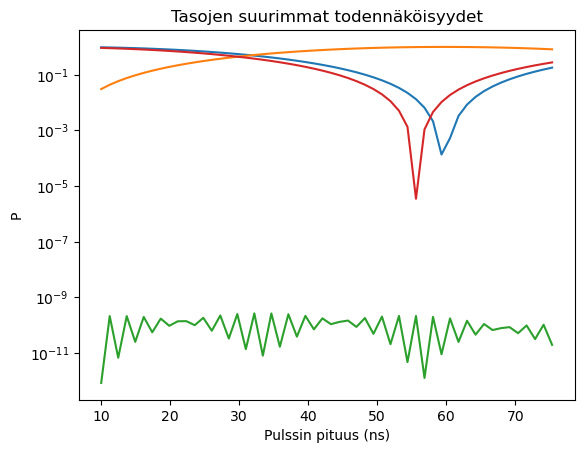

---------------------------------------------


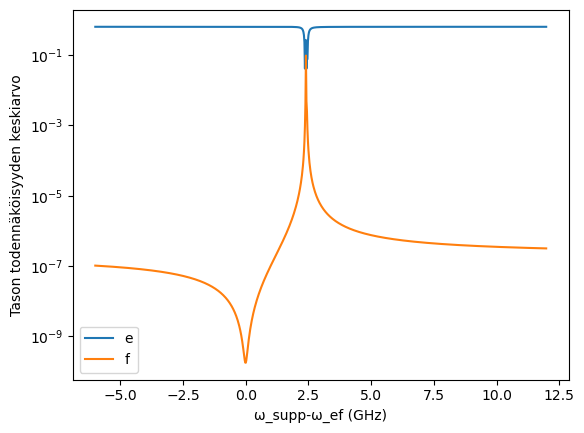

Amplitudi (GHz): 0.06506300881003034
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999859523423194
Pulssin pituus (ns): 51.90803331550285
Rabi-taajuus (fourier):  0.010357025105993845


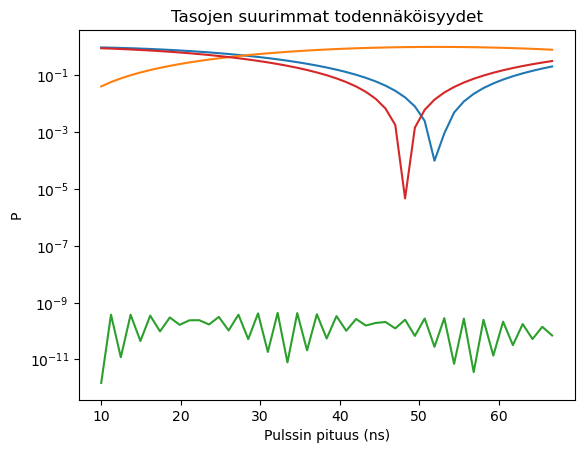

---------------------------------------------


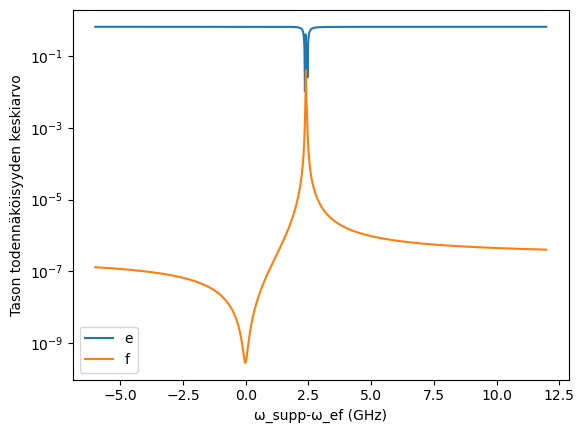

Amplitudi (GHz): 0.0737827934959107
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999977058950621
Pulssin pituus (ns): 46.978006381587
Rabi-taajuus (fourier):  0.011757870454372307


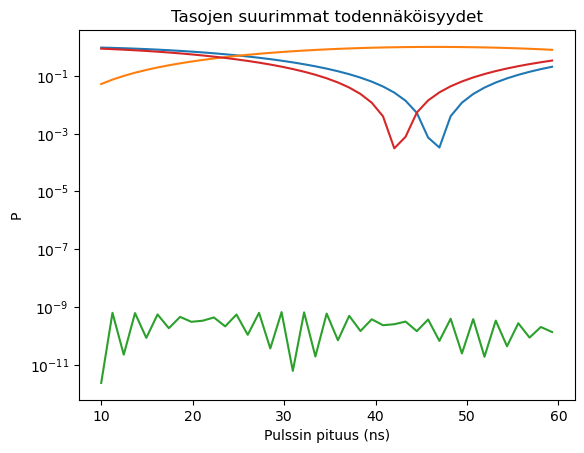

---------------------------------------------


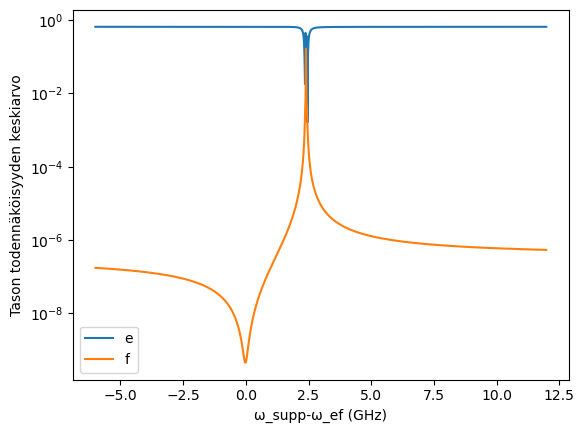

Amplitudi (GHz): 0.08250257818179106
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999999851616981
Pulssin pituus (ns): 42.04797373135661
Rabi-taajuus (fourier):  0.013155952546512974


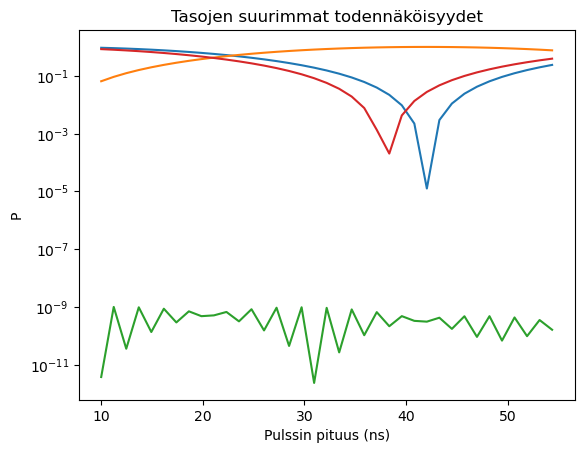

---------------------------------------------


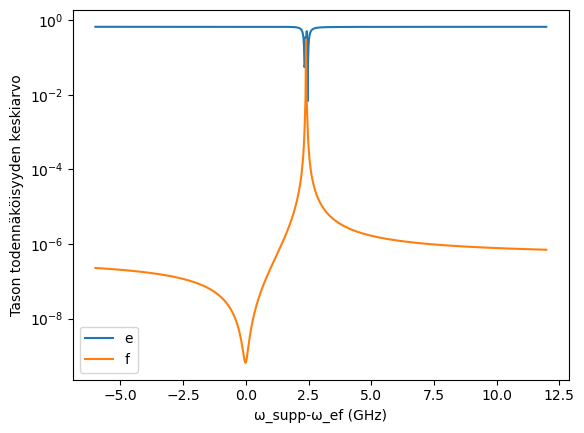

Amplitudi (GHz): 0.09122236286767142
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.999978118665121
Pulssin pituus (ns): 37.11821660371552
Rabi-taajuus (fourier):  0.014530079780109211


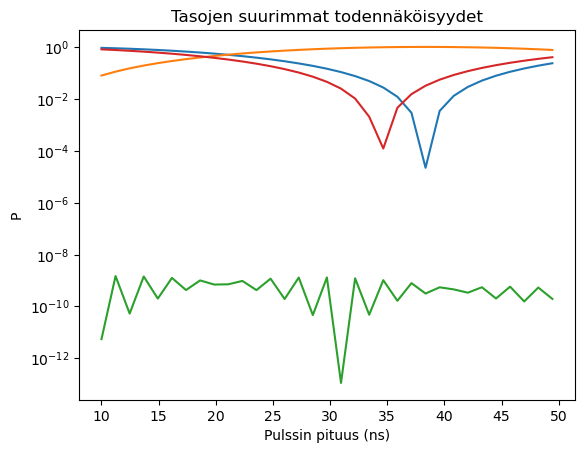

---------------------------------------------


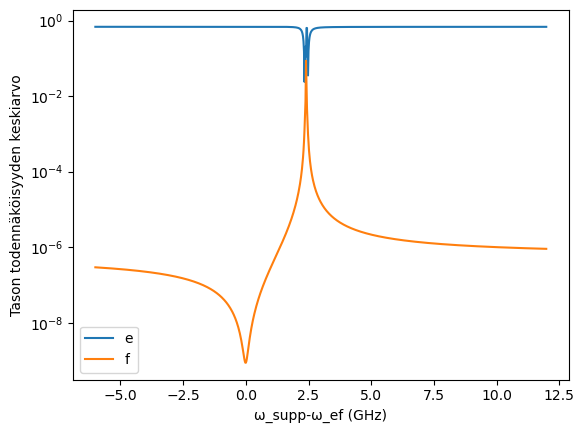

Amplitudi (GHz): 0.0999421475535518
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999744911366315
Pulssin pituus (ns): 34.65314053734538
Rabi-taajuus (fourier):  0.01590697388639172


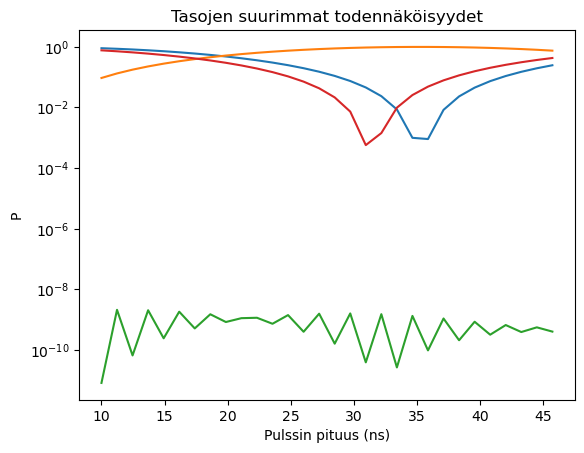

---------------------------------------------


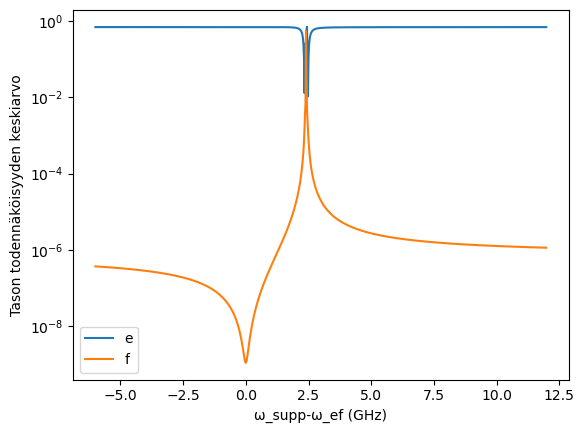

Amplitudi (GHz): 0.10866193223943212
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9998641856343552
Pulssin pituus (ns): 32.18816521777326
Rabi-taajuus (fourier):  0.017321920638251297


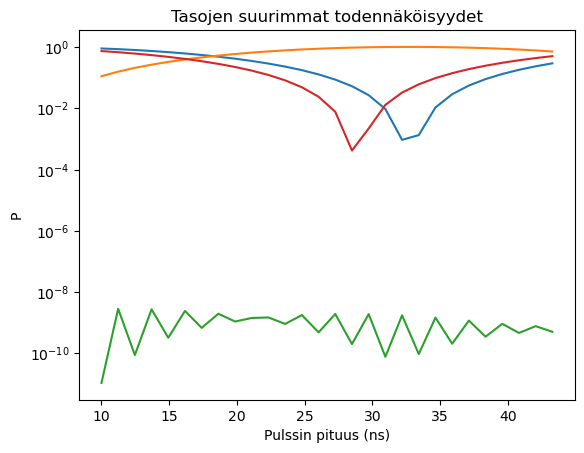

---------------------------------------------


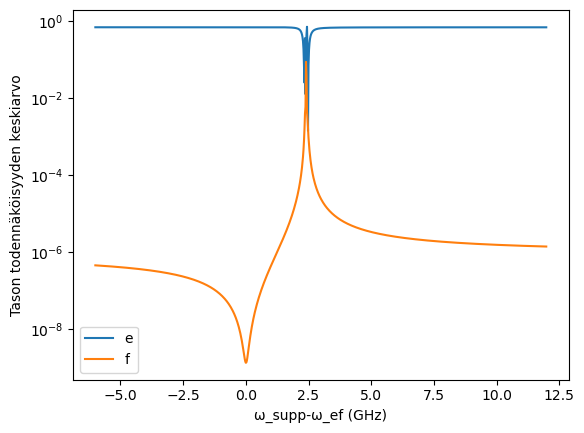

Amplitudi (GHz): 0.11738171692531249
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999756794403862
Pulssin pituus (ns): 29.723320041631027
Rabi-taajuus (fourier):  0.018720518069544813


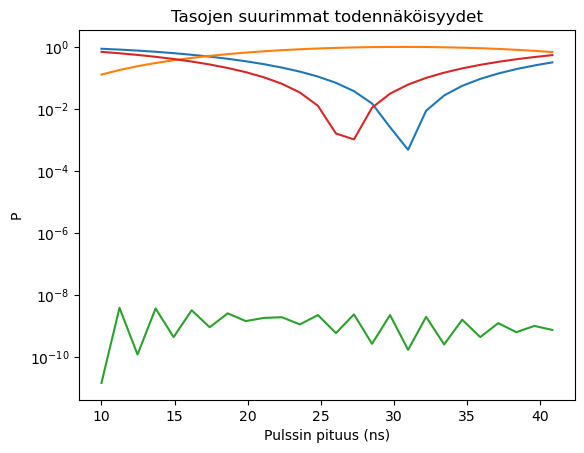

---------------------------------------------


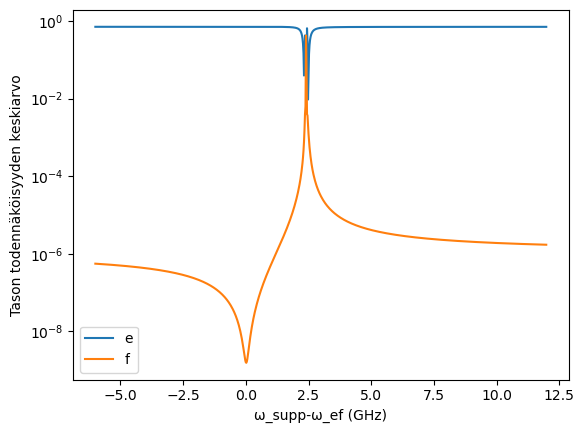

Amplitudi (GHz): 0.12610150161119285
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999363797845106
Pulssin pituus (ns): 29.722716352290508
Rabi-taajuus (fourier):  0.020113568931896267


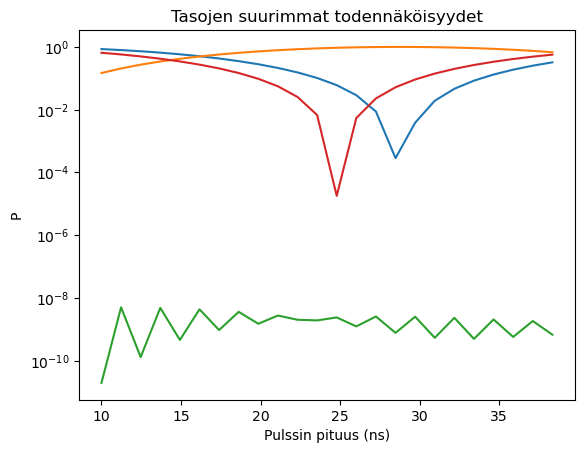

---------------------------------------------


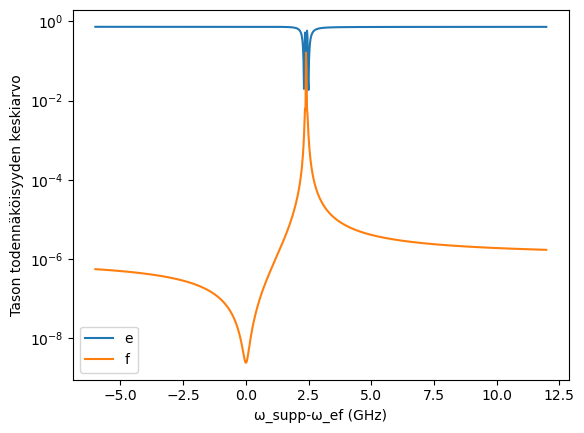

Amplitudi (GHz): 0.13482128629707318
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999958597932609
Pulssin pituus (ns): 27.011500553134766
Rabi-taajuus (fourier):  0.02146073851269338


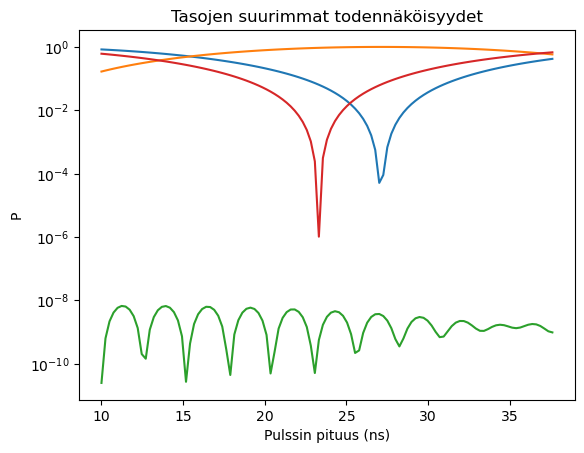

---------------------------------------------


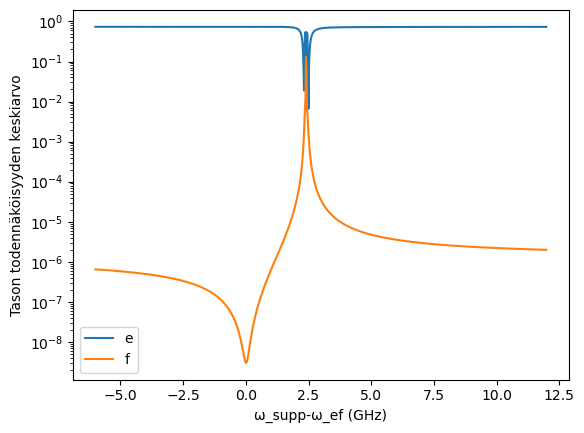

Amplitudi (GHz): 0.14354107098295354
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.999946283693454
Pulssin pituus (ns): 25.779743316108707
Rabi-taajuus (fourier):  0.022849762068918467


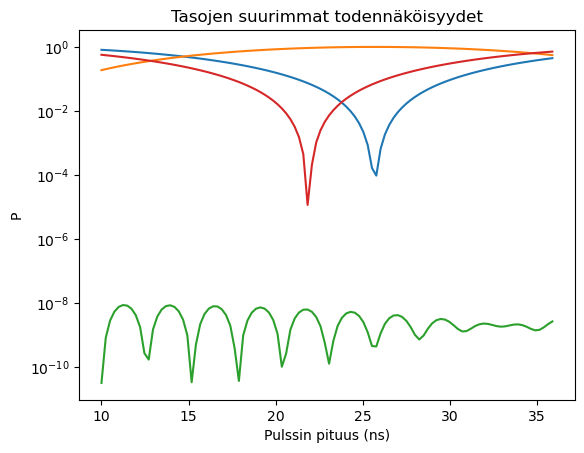

---------------------------------------------


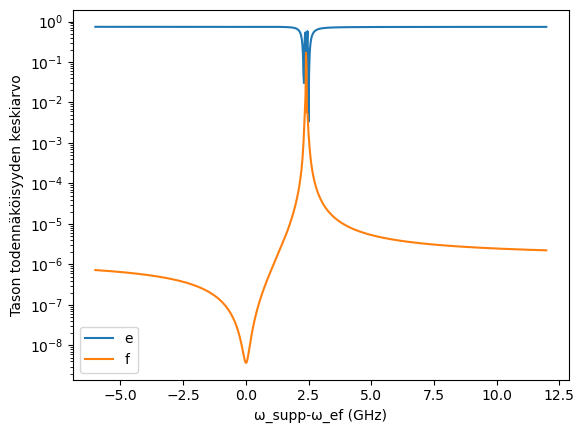

Amplitudi (GHz): 0.15226085566883393
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.999969135604174
Pulssin pituus (ns): 24.54644637157886
Rabi-taajuus (fourier):  0.024238885046395875


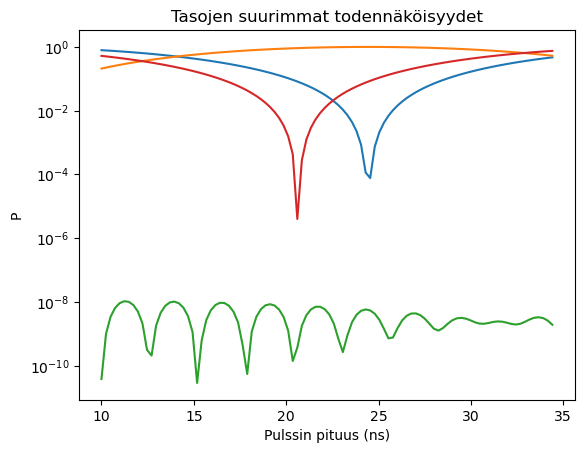

---------------------------------------------


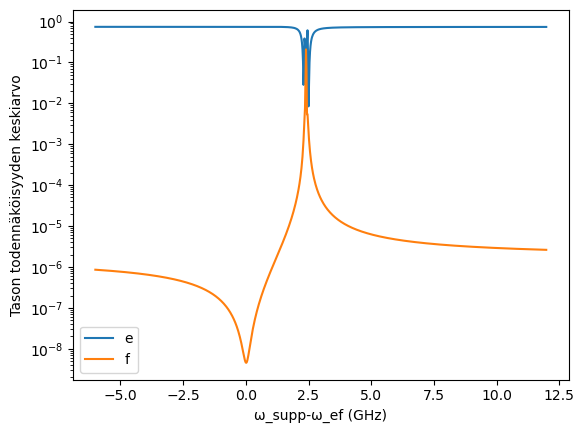

Amplitudi (GHz): 0.16098064035471424
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999224871187214
Pulssin pituus (ns): 23.314941003197596
Rabi-taajuus (fourier):  0.025641271152677194


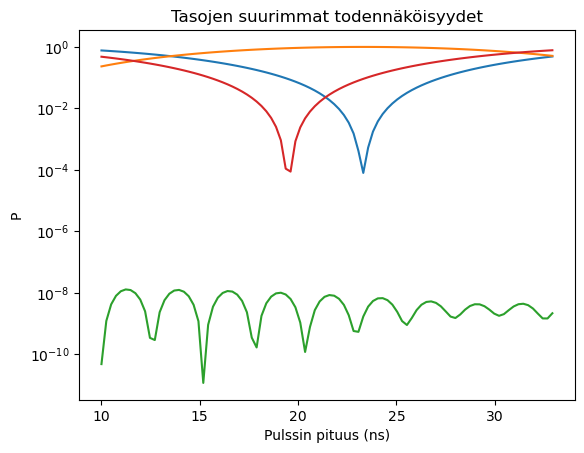

---------------------------------------------


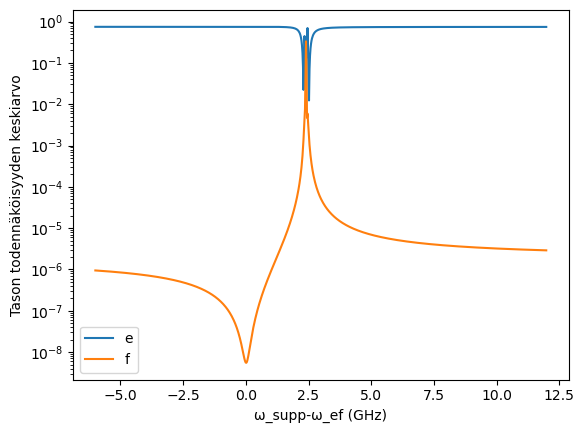

Amplitudi (GHz): 0.16970042504059463
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999993886014489
Pulssin pituus (ns): 22.32818802722184
Rabi-taajuus (fourier):  0.027038307056746817


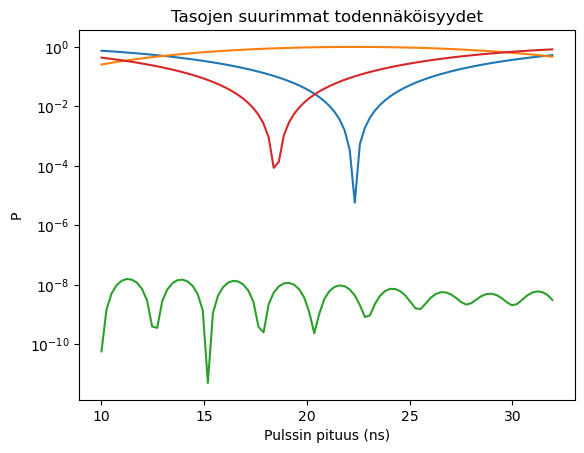

---------------------------------------------


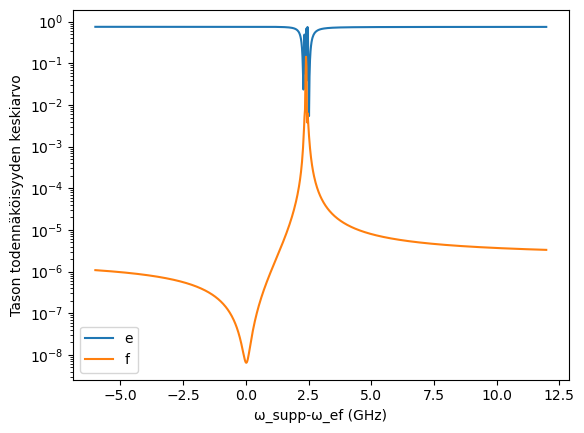

Amplitudi (GHz): 0.178420209726475
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999005656210271
Pulssin pituus (ns): 21.341493461055187
Rabi-taajuus (fourier):  0.028429228271323152


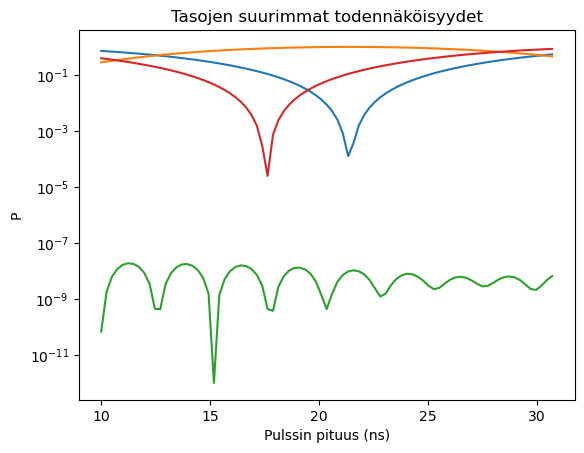

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=5*A/3 #Arvaus Rabi-taajuudelle
    AC_stark=0 #Arvaus AC-stark siirtymälle

    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi,AC_stark,[-300,600],50)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    if A < 0.13:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=5,drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=1,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694748212), np.float64(0.021464085380628568), np.float64(0.030183870066508925), np.float64(0.03890365475238928), np.float64(0.04762343943826964), np.float64(0.05634322412415), np.float64(0.06506300881003034), np.float64(0.0737827934959107), np.float64(0.08250257818179106), np.float64(0.09122236286767142), np.float64(0.0999421475535518), np.float64(0.10866193223943212), np.float64(0.11738171692531249), np.float64(0.12610150161119285), np.float64(0.13482128629707318), np.float64(0.14354107098295354), np.float64(0.15226085566883393), np.float64(0.16098064035471424), np.float64(0.16970042504059463), np.float64(0.178420209726475)]


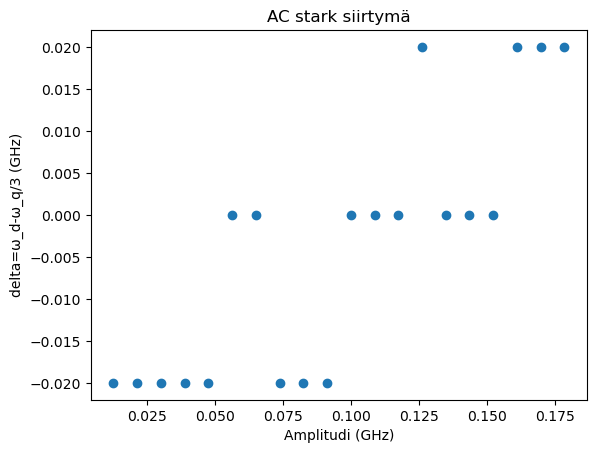

[-0.02, -0.02, -0.02, -0.02, -0.02, 0.0, 0.0, -0.02, -0.02, -0.02, 0.0, 0.0, 0.0, 0.02, 0.0, 0.0, 0.0, 0.02, 0.02, 0.02]


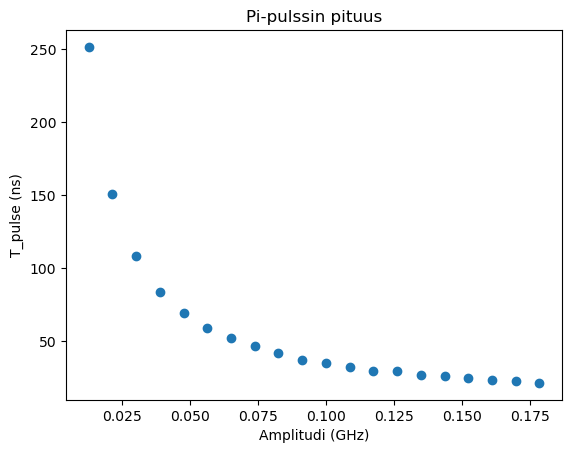

[np.float64(251.57999227526173), np.float64(150.51100417886914), np.float64(108.60460151978626), np.float64(83.95393200135018), np.float64(69.16345002618263), np.float64(59.30325525761684), np.float64(51.90803331550285), np.float64(46.978006381587), np.float64(42.04797373135661), np.float64(37.11821660371552), np.float64(34.65314053734538), np.float64(32.18816521777326), np.float64(29.723320041631027), np.float64(29.722716352290508), np.float64(27.011500553134766), np.float64(25.779743316108707), np.float64(24.54644637157886), np.float64(23.314941003197596), np.float64(22.32818802722184), np.float64(21.341493461055187)]


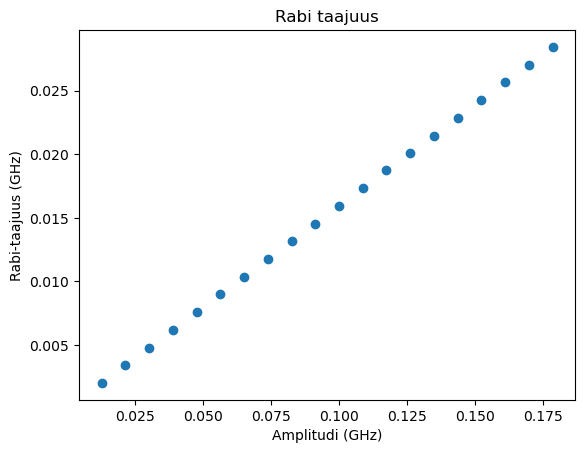

[np.float64(0.0020291591499556868), np.float64(0.003418501500709659), np.float64(0.004805456050428481), np.float64(0.0061932510521172865), np.float64(0.007582352459881833), np.float64(0.008981241212787306), np.float64(0.010357025105993845), np.float64(0.011757870454372307), np.float64(0.013155952546512974), np.float64(0.014530079780109211), np.float64(0.01590697388639172), np.float64(0.017321920638251297), np.float64(0.018720518069544813), np.float64(0.020113568931896267), np.float64(0.02146073851269338), np.float64(0.022849762068918467), np.float64(0.024238885046395875), np.float64(0.025641271152677194), np.float64(0.027038307056746817), np.float64(0.028429228271323152)]


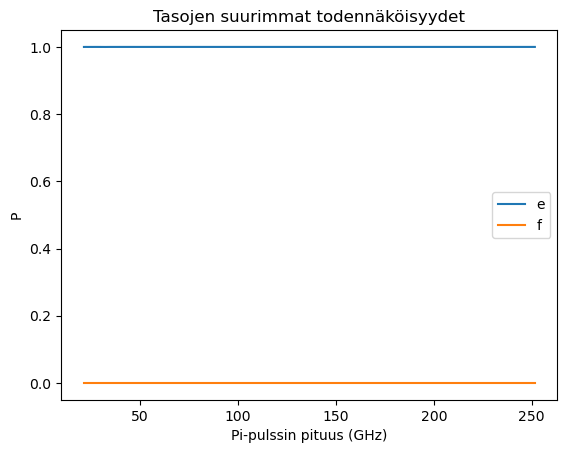

[np.float64(0.9999953367006645), np.float64(0.9999993016939162), np.float64(0.9999996733490408), np.float64(0.9999967107851442), np.float64(0.9999993663141789), np.float64(0.9999995019293609), np.float64(0.9999859523423194), np.float64(0.9999977058950621), np.float64(0.9999999851616981), np.float64(0.999978118665121), np.float64(0.9999744911366315), np.float64(0.9998641856343552), np.float64(0.9999756794403862), np.float64(0.9999363797845106), np.float64(0.9999958597932609), np.float64(0.999946283693454), np.float64(0.999969135604174), np.float64(0.9999224871187214), np.float64(0.9999993886014489), np.float64(0.9999005656210271)]
[np.float64(3.371080205624995e-12), np.float64(1.3168744989565482e-11), np.float64(3.5187245858716895e-11), np.float64(7.782537752434112e-11), np.float64(1.4740553225084652e-10), np.float64(2.6551455742985336e-10), np.float64(4.361948983451261e-10), np.float64(7.002084814402054e-10), np.float64(1.0581655865538891e-09), np.float64(1.5511498533660454e-09), np.fl

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

In [10]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0070
N_data=20
d_data=(max_range-min_range)/(N_data-1)

i=10
A = qubit.frequency*(min_range+i*d_data)
A_vals.append(A)

f_d_opt = qubit.frequency+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

f_rabi=5*A/3 #Arvaus Rabi-taajuudelle
AC_stark=0 #Arvaus AC-stark siirtymälle

params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi,AC_stark,[-300,600],50)

deltas.append(params[0])
pulse_lengths.append(params[1])
data.append(params[3])

m=10

if A < 0.13:
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=5,drag=True)
else:
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=1,drag=True)

print("Amplitudi (GHz):", A)
print("AC-stark siirtymä (GHz):", deltas[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("Pulssin pituus (ns):", pulse_lengths[-1])

max_vals.append([vals[0],vals[1]])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

#Taajuusavaruus
freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

magnitude = np.abs(fft_vals) #Taajuuskomponentit
magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
print("Rabi-taajuus (fourier): ",frequency)
rabis.append(frequency)

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], plot_vals)
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

-300
-299


KeyboardInterrupt: 